# TECHMIND - Organizacion Inteligente del Conocimiento Tecnico
## Hackathon ONE (Oracle Next Education + Alura + NoCountry) - Grupo G9
### Rol: Equipo de Ciencia de Datos


---
## PASO 1: Instalar librerias necesarias


---
## PASO 2: Importar las librerias



In [25]:
import os
import re
import joblib
import pandas as pd
import numpy as np

# Librerias para hacer graficos
import matplotlib.pyplot as plt
import seaborn as sns

# Modulos de Scikit-Learn (Machine Learning)
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# skl2onnx: convierte modelos de scikit-learn a formato ONNX
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import StringTensorType

# Configuracion de graficos
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 10

# Configuracion de Pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

print("PASO 2 COMPLETADO: Librerias cargadas correctamente.")

PASO 2 COMPLETADO: Librerias cargadas correctamente.


---
## PASO 3: Cargar el dataset


**Importante:** En Google Colab, debes subir el archivo manualmente.
1. Ejecuta la siguiente celda
2. Haz clic en "Choose Files" (Seleccionar archivos)
3. Selecciona el archivo `dataset_hackaton_lenguajes_traducido.csv`

In [26]:
from google.colab import files

print("Por favor, selecciona el archivo 'dataset_hackaton_lenguajes_traducido.csv'")
archivo_subido = files.upload()

# Obtener el nombre del archivo subido
nombre_archivo = list(archivo_subido.keys())[0]
print(f"\nArchivo recibido: {nombre_archivo}")
print(f"Tamano: {os.path.getsize(nombre_archivo) / 1024:.1f} KB")

Por favor, selecciona el archivo 'dataset_hackaton_lenguajes_traducido.csv'


Saving dataset_hackaton_lenguajes_traducido.csv to dataset_hackaton_lenguajes_traducido (1).csv

Archivo recibido: dataset_hackaton_lenguajes_traducido (1).csv
Tamano: 16470.4 KB


---
## PASO 4: Leer el dataset



In [27]:
ruta_dataset = nombre_archivo

opciones_lectura = {
    'on_bad_lines': 'skip',
    'engine': 'python'
}

try:
    df = pd.read_csv(ruta_dataset, encoding='utf-8', **opciones_lectura)
    print("Archivo leido exitosamente con codificacion UTF-8.")
except UnicodeDecodeError:
    print("UTF-8 fallo, intentando con codificacion 'latin-1'...")
    df = pd.read_csv(ruta_dataset, encoding='latin-1', **opciones_lectura)
    print("Archivo leido exitosamente con codificacion latin-1.")

print(f"\nTotal de registros cargados: {len(df)}")
print(f"Total de columnas: {len(df.columns)}")

UTF-8 fallo, intentando con codificacion 'latin-1'...
Archivo leido exitosamente con codificacion latin-1.

Total de registros cargados: 5524
Total de columnas: 10


---
## PASO 5: Analisis Exploratorio de Datos (EDA)



In [28]:
print("=" * 80)
print("ANALISIS EXPLORATORIO DE DATOS (EDA)")
print("=" * 80)

# --- Mostrar las columnas disponibles ---
print("\nCOLUMNAS DEL DATASET:")
for i, col in enumerate(df.columns, 1):
    print(f"   {i}. {col}")

# --- Mostrar una muestra de los datos ---
print("\nMUESTRA DE LOS PRIMEROS REGISTROS:")
display(df[['id', 'titulo', 'categoria', 'lenguaje']].head(3))

ANALISIS EXPLORATORIO DE DATOS (EDA)

COLUMNAS DEL DATASET:
   1. id
   2. title
   3. titulo
   4. subtitle
   5. subtitulo
   6. description
   7. descripcion
   8. categorias
   9. lenguaje
   10. categoria

MUESTRA DE LOS PRIMEROS REGISTROS:


,id,titulo,categoria,lenguaje
0,0,JavaScript práctico para desarrolladores de Python,backend,Python
1,1,Visualización de datos con Python y JavaScript,backend,Python
2,2,Gestión de datos con Python,backend,Python


In [29]:
# --- Verificar valores nulos (informacion faltante) ---
print("DIAGNOSTICO DE VALORES NULOS (informacion faltante):")

nulos_absolutos = df.isnull().sum()
nulos_porcentaje = (df.isnull().sum() / len(df)) * 100

tabla_nulos = pd.DataFrame({
    'Valores Nulos': nulos_absolutos,
    'Porcentaje del Total (%)': nulos_porcentaje.round(2)
})

columnas_con_nulos = tabla_nulos[tabla_nulos['Valores Nulos'] > 0]
if len(columnas_con_nulos) > 0:
    display(columnas_con_nulos)
else:
    print("   No hay valores nulos en ninguna columna!")

# --- Verificar filas duplicadas ---
filas_duplicadas = df.duplicated().sum()
if filas_duplicadas > 0:
    print(f"\nFilas duplicadas encontradas: {filas_duplicadas}")
else:
    print(f"\nNo hay filas duplicadas: {filas_duplicadas}")

DIAGNOSTICO DE VALORES NULOS (informacion faltante):


,Valores Nulos,Porcentaje del Total (%)
title,2,0.04
titulo,2,0.04
subtitle,2558,46.31
subtitulo,2558,46.31
description,2,0.04
descripcion,2,0.04
categorias,2,0.04
lenguaje,4382,79.33
categoria,4382,79.33



No hay filas duplicadas: 0


In [30]:
# --- Mostrar estadisticas basicas de los textos ---
print("ESTADISTICAS BASICAS DE LOS TEXTOS:")

longitud_titulos = df['titulo'].fillna('').astype(str).apply(len)
longitud_descripciones = df['descripcion'].fillna('').astype(str).apply(len)

print(f"   Titulos:")
print(f"      - Longitud promedio: {longitud_titulos.mean():.0f} caracteres")
print(f"      - Titulo mas corto:  {longitud_titulos.min()} caracteres")
print(f"      - Titulo mas largo:  {longitud_titulos.max()} caracteres")
print(f"   Descripciones:")
print(f"      - Longitud promedio: {longitud_descripciones.mean():.0f} caracteres")
print(f"      - Descripcion mas corta:  {longitud_descripciones.min()} caracteres")
print(f"      - Descripcion mas larga:  {longitud_descripciones.max()} caracteres")

ESTADISTICAS BASICAS DE LOS TEXTOS:
   Titulos:
      - Longitud promedio: 41 caracteres
      - Titulo mas corto:  0 caracteres
      - Titulo mas largo:  244 caracteres
   Descripciones:
      - Longitud promedio: 1417 caracteres
      - Descripcion mas corta:  0 caracteres
      - Descripcion mas larga:  3424 caracteres


In [31]:
# --- Mostrar las categorias y lenguajes disponibles ---
print("CATEGORIAS DISPONIBLES:")
categorias_disponibles = df['categoria'].fillna('').astype(str).str.strip().str.lower()
categorias_disponibles = categorias_disponibles[categorias_disponibles != '']
print(f"   Total de categorias unicas: {categorias_disponibles.nunique()}")
print(f"   Ejemplos: {list(categorias_disponibles.unique()[:10])}")

print("\nLENGUAJES DISPONIBLES:")
lenguajes_disponibles = df['lenguaje'].fillna('').astype(str).str.strip().str.capitalize()
lenguajes_disponibles = lenguajes_disponibles[lenguajes_disponibles != '']
print(f"   Total de lenguajes unicos: {lenguajes_disponibles.nunique()}")
print(f"   Ejemplos: {list(lenguajes_disponibles.unique()[:10])}")

CATEGORIAS DISPONIBLES:
   Total de categorias unicas: 3
   Ejemplos: ['backend', 'full stack', 'frontend']

LENGUAJES DISPONIBLES:
   Total de lenguajes unicos: 14
   Ejemplos: ['Python', 'Php', 'C#', 'C++', 'Haskell', 'Java', 'C', 'Perl', 'Javascript', 'Css']


---
## PASO 6: Visualizaciones



GENERANDO GRAFICOS EXPLORATORIOS...

Generando grafico: Top 10 Categorias...


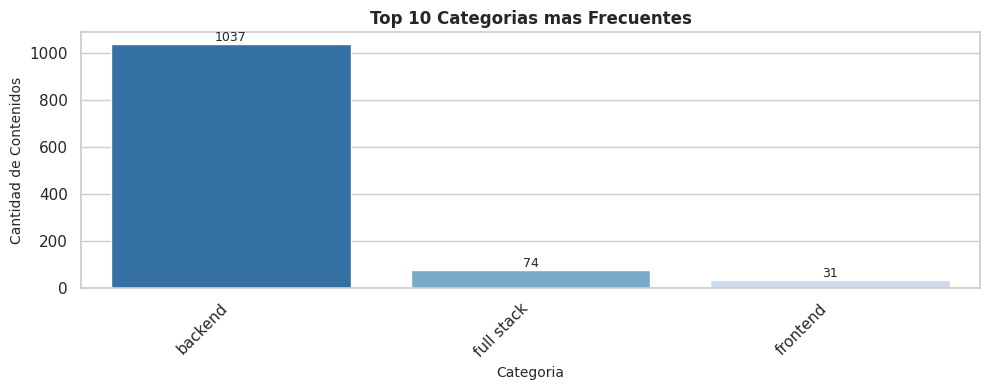

Grafico de categorias generado.


In [32]:
print("GENERANDO GRAFICOS EXPLORATORIOS...")

valores_invalidos = ['', 'nan', 'none', '#valor!', '#valor!']

cat_para_grafico = categorias_disponibles[~categorias_disponibles.isin(valores_invalidos)]
len_para_grafico = lenguajes_disponibles[~lenguajes_disponibles.isin(valores_invalidos)]

# --- GRAFICO 1: Top 10 Categorias ---
print("\nGenerando grafico: Top 10 Categorias...")
top_categorias = cat_para_grafico.value_counts().head(10)

plt.figure(figsize=(10, 4))
grafico_cat = sns.barplot(
    x=top_categorias.index,
    y=top_categorias.values,
    hue=top_categorias.index,
    palette="Blues_r",
    legend=False
)
plt.title("Top 10 Categorias mas Frecuentes", fontsize=12, fontweight='bold')
plt.xlabel("Categoria", fontsize=10)
plt.ylabel("Cantidad de Contenidos", fontsize=10)
plt.xticks(rotation=45, ha='right')

for barra in grafico_cat.patches:
    if barra.get_height() > 0:
        grafico_cat.annotate(
            f'{int(barra.get_height())}',
            (barra.get_x() + barra.get_width() / 2., barra.get_height()),
            ha='center', va='bottom', fontsize=9
        )
plt.tight_layout()
plt.show()
print("Grafico de categorias generado.")

Generando grafico: Top 10 Lenguajes de Programacion...


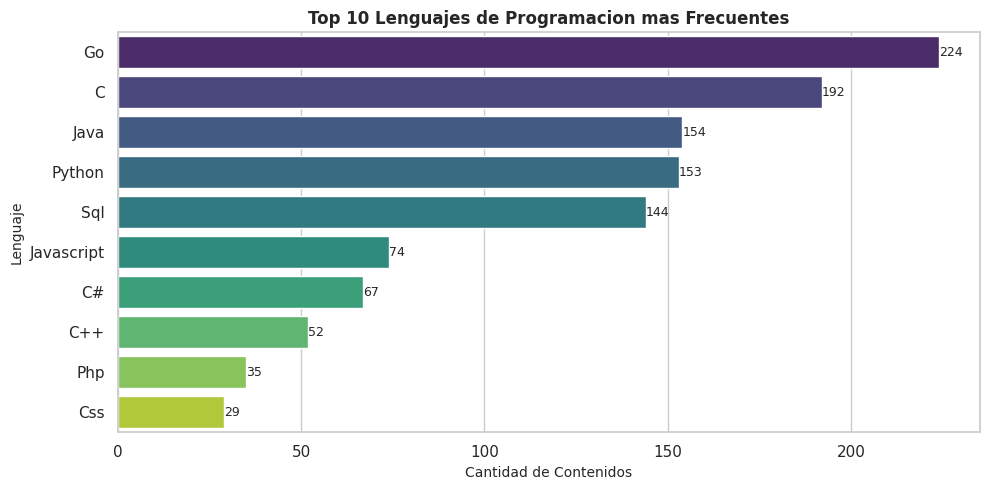

Grafico de lenguajes generado.


In [33]:
# --- GRAFICO 2: Top 10 Lenguajes ---
print("Generando grafico: Top 10 Lenguajes de Programacion...")
top_lenguajes = len_para_grafico.value_counts().head(10)

plt.figure(figsize=(10, 5))
grafico_len = sns.barplot(
    y=top_lenguajes.index,
    x=top_lenguajes.values,
    hue=top_lenguajes.index,
    palette="viridis",
    legend=False
)
plt.title("Top 10 Lenguajes de Programacion mas Frecuentes", fontsize=12, fontweight='bold')
plt.xlabel("Cantidad de Contenidos", fontsize=10)
plt.ylabel("Lenguaje", fontsize=10)

for barra in grafico_len.patches:
    if barra.get_width() > 0:
        grafico_len.annotate(
            f'{int(barra.get_width())}',
            (barra.get_width(), barra.get_y() + barra.get_height() / 2.),
            ha='left', va='center', fontsize=9
        )
plt.tight_layout()
plt.show()
print("Grafico de lenguajes generado.")

Generando grafico: Distribucion de palabras en los textos...


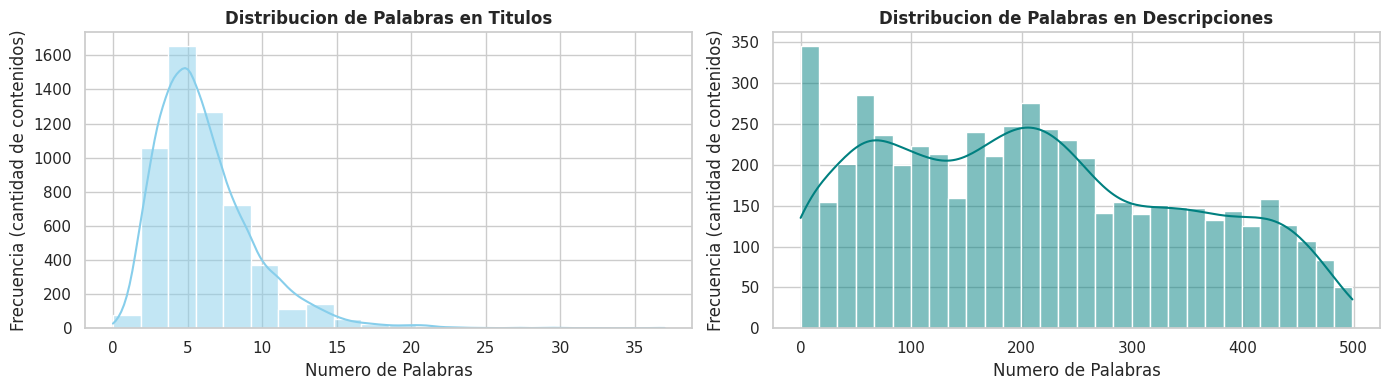

Grafico de distribucion de palabras generado.


In [34]:
# --- GRAFICO 3: Distribucion de palabras en titulos y descripciones ---
print("Generando grafico: Distribucion de palabras en los textos...")

df_temp = df.copy()
df_temp['palabras_titulo'] = df_temp['titulo'].fillna('').astype(str).apply(lambda x: len(x.split()))
df_temp['palabras_descripcion'] = df_temp['descripcion'].fillna('').astype(str).apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df_temp['palabras_titulo'], kde=True, ax=axes[0], color='skyblue', bins=20)
axes[0].set_title("Distribucion de Palabras en Titulos", fontweight='bold')
axes[0].set_xlabel("Numero de Palabras")
axes[0].set_ylabel("Frecuencia (cantidad de contenidos)")

sns.histplot(
    df_temp['palabras_descripcion'][df_temp['palabras_descripcion'] < 500],
    kde=True, ax=axes[1], color='teal', bins=30
)
axes[1].set_title("Distribucion de Palabras en Descripciones", fontweight='bold')
axes[1].set_xlabel("Numero de Palabras")
axes[1].set_ylabel("Frecuencia (cantidad de contenidos)")

plt.tight_layout()
plt.show()
print("Grafico de distribucion de palabras generado.")

---
## PASO 7: Funcion de limpieza de texto

Esta funcion prepara los textos para que el modelo pueda entenderlos. Convierte todo a minusculas, elimina signos de puntuacion, numeros y espacios de mas.

In [35]:
def limpiar_texto(texto):
    """
    LIMPIA y PREPARA un texto para que el modelo pueda entenderlo.

    Convierte todo a minusculas, elimina signos de puntuacion,
    numeros y espacios de mas.
    """
    texto = str(texto).lower()
    texto = re.sub(r'[^\w\s]', ' ', texto)
    texto = re.sub(r'\d+', ' ', texto)
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto

print("Funcion de limpieza de texto creada.")

Funcion de limpieza de texto creada.


---
## PASO 8: Preprocesamiento de textos

Preparar los textos para que el modelo pueda entenderlos.

In [36]:
print("PREPROCESAMIENTO DE TEXTOS")
print("Vamos a limpiar y preparar los textos para el modelo...")

# Estandarizar las columnas de categoria y lenguaje
df['categoria'] = df['categoria'].fillna('').astype(str).str.strip().str.lower()
df['lenguaje'] = df['lenguaje'].fillna('').astype(str).str.strip().str.capitalize()

# Eliminar filas con datos invalidos
print("\nEliminando registros con datos invalidos o vacios...")
df_limpio = df[
    ~df['categoria'].isin(valores_invalidos) &
    ~df['lenguaje'].isin(valores_invalidos)
].copy()
print(f"Registros despues de limpieza: {len(df_limpio)}")
print(f"(Se eliminaron {len(df) - len(df_limpio)} registros con datos invalidos)")

# Combinar todos los campos de texto en UN SOLO TEXTO COMPLETO
print("\nCombinando todos los campos de texto en uno solo...")
columnas_texto = ['titulo', 'title', 'subtitulo', 'subtitle', 'descripcion', 'description', 'categorias']

for col in columnas_texto:
    df_limpio[col] = df_limpio[col].fillna('').astype(str)

df_limpio['texto_completo'] = (
    df_limpio['titulo'] + " " +
    df_limpio['title'] + " " +
    df_limpio['subtitulo'] + " " +
    df_limpio['subtitle'] + " " +
    df_limpio['descripcion'] + " " +
    df_limpio['description'] + " " +
    df_limpio['categorias']
)
print("Todos los textos combinados en una sola columna 'texto_completo'.")

# Aplicar la limpieza de texto
print("\nLimpiando y normalizando los textos (minusculas, sin puntuacion)...")
df_limpio['texto_limpio'] = df_limpio['texto_completo'].apply(limpiar_texto)

# Eliminar textos muy cortos
df_limpio = df_limpio[df_limpio['texto_limpio'].str.len() > 10].copy()
print(f"Textos limpios y listos. Total de registros utiles: {len(df_limpio)}")

PREPROCESAMIENTO DE TEXTOS
Vamos a limpiar y preparar los textos para el modelo...

Eliminando registros con datos invalidos o vacios...
Registros despues de limpieza: 1142
(Se eliminaron 4382 registros con datos invalidos)

Combinando todos los campos de texto en uno solo...
Todos los textos combinados en una sola columna 'texto_completo'.

Limpiando y normalizando los textos (minusculas, sin puntuacion)...
Textos limpios y listos. Total de registros utiles: 1142


---
## PASO 9: Preparar datos para el modelo

Ahora separamos los datos en:
- **X**: Los textos de entrada (lo que el modelo va a leer)
- **y_categoria**: La categoria a predecir (backend, frontend, full stack)
- **y_lenguaje**: El lenguaje a predecir (Python, Java, etc.)

Luego dividimos en **entrenamiento (80%)** y **prueba (20%)**.

In [ ]:
print("PREPARANDO DATOS PARA EL ENTRENAMIENTO")

# Filtramos categorias y lenguajes que aparezcan al menos 2 veces
categorias_validas = df_limpio['categoria'].value_counts()
categorias_validas = categorias_validas[categorias_validas >= 2].index

lenguajes_validos = df_limpio['lenguaje'].value_counts()
lenguajes_validos = lenguajes_validos[lenguajes_validos >= 2].index

df_filtrado = df_limpio[
    df_limpio['categoria'].isin(categorias_validas) &
    df_limpio['lenguaje'].isin(lenguajes_validos)
].copy()

print(f"\nRegistros despues de filtrar categorias/lenguajes poco frecuentes: {len(df_filtrado)}")

X = df_filtrado['texto_limpio']
y_categoria = df_filtrado['categoria']
y_lenguaje = df_filtrado['lenguaje']

print("\nDividiendo datos en entrenamiento (80%) y prueba (20%)...")
X_train, X_test, y_cat_train, y_cat_test, y_len_train, y_len_test = train_test_split(
    X,
    y_categoria,
    y_lenguaje,
    test_size=0.2,
    random_state=42
)

print(f"\nDistribucion final de datos:")
print(f"   - Entrenamiento: {len(X_train)} ejemplos (para que el modelo aprenda)")
print(f"   - Prueba:        {len(X_test)} ejemplos (para evaluar al modelo)")

PREPARANDO DATOS PARA EL ENTRENAMIENTO

Registros despues de filtrar categorias/lenguajes poco frecuentes: 1142

Dividiendo datos en entrenamiento (80%) y prueba (20%)...

Distribucion final de datos:
   - Entrenamiento: 913 ejemplos (para que el modelo aprenda)
   - Prueba:        229 ejemplos (para evaluar al modelo)


---
## PASO 9b: Graficos del dataset limpio


Generando grafico: Distribucion final de CATEGORIAS...


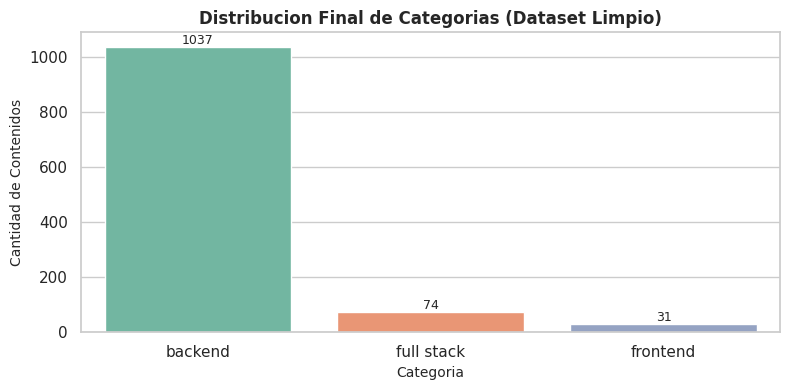

Grafico de distribucion final de categorias generado.


In [ ]:
# --- GRAFICO 5: Distribucion final de categorias (post-limpieza) ---
print("Generando grafico: Distribucion final de CATEGORIAS...")
plt.figure(figsize=(8, 4))
conteo_cat_final = df_filtrado['categoria'].value_counts()
grafico_cat_final = sns.barplot(
    x=conteo_cat_final.index,
    y=conteo_cat_final.values,
    hue=conteo_cat_final.index,
    palette="Set2",
    legend=False
)
plt.title("Distribucion Final de Categorias (Dataset Limpio)", fontsize=12, fontweight='bold')
plt.xlabel("Categoria", fontsize=10)
plt.ylabel("Cantidad de Contenidos", fontsize=10)
for barra in grafico_cat_final.patches:
    if barra.get_height() > 0:
        grafico_cat_final.annotate(
            f'{int(barra.get_height())}',
            (barra.get_x() + barra.get_width() / 2., barra.get_height()),
            ha='center', va='bottom', fontsize=9
        )
plt.tight_layout()
plt.show()
print("Grafico de distribucion final de categorias generado.")

Generando grafico: Top 10 LENGUAJES (post-limpieza)...


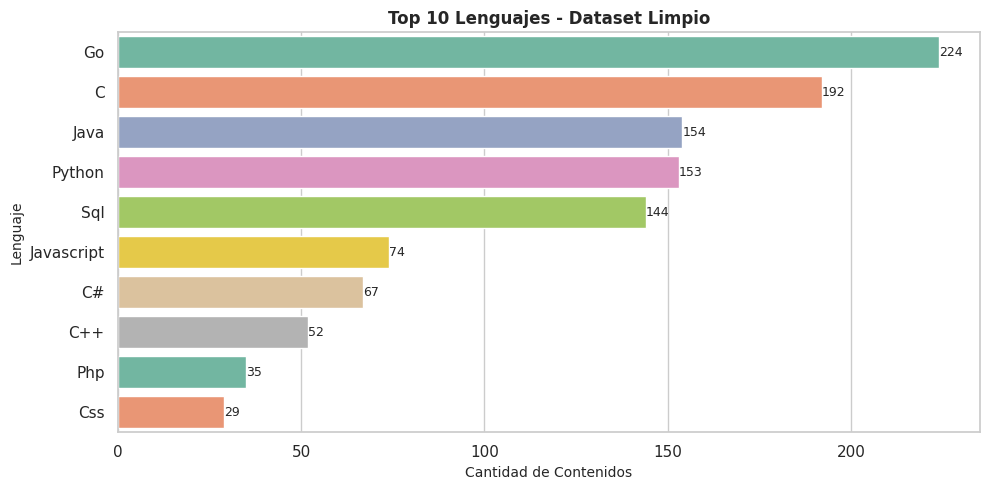

Grafico de lenguajes post-limpieza generado.


In [ ]:
# --- GRAFICO 6: Top 10 lenguajes post-limpieza ---
print("Generando grafico: Top 10 LENGUAJES (post-limpieza)...")
plt.figure(figsize=(10, 5))
top_leng_final = df_filtrado['lenguaje'].value_counts().head(10)
grafico_len_final = sns.barplot(
    y=top_leng_final.index,
    x=top_leng_final.values,
    hue=top_leng_final.index,
    palette="Set2",
    legend=False
)
plt.title("Top 10 Lenguajes - Dataset Limpio", fontsize=12, fontweight='bold')
plt.xlabel("Cantidad de Contenidos", fontsize=10)
plt.ylabel("Lenguaje", fontsize=10)
for barra in grafico_len_final.patches:
    if barra.get_width() > 0:
        grafico_len_final.annotate(
            f'{int(barra.get_width())}',
            (barra.get_width(), barra.get_y() + barra.get_height() / 2.),
            ha='left', va='center', fontsize=9
        )
plt.tight_layout()
plt.show()
print("Grafico de lenguajes post-limpieza generado.")

In [ ]:
# --- Resumen de limpieza ---
print("RESUMEN DE LIMPIEZA:")
print(f"   - Dataset original: {len(df)} registros")
print(f"   - Despues de limpiar: {len(df_limpio)} registros")
print(f"   - Despues de filtrar: {len(df_filtrado)} registros")
print(f"   - Categorias disponibles: {list(df_filtrado['categoria'].unique())}")
print(f"   - Lenguajes disponibles: {len(df_filtrado['lenguaje'].unique())}")
print("Dataset listo para el entrenamiento.")

RESUMEN DE LIMPIEZA:
   - Dataset original: 5524 registros
   - Despues de limpiar: 1142 registros
   - Despues de filtrar: 1142 registros
   - Categorias disponibles: ['backend', 'full stack', 'frontend']
   - Lenguajes disponibles: 14
Dataset listo para el entrenamiento.
